# Tree-Model Attack Comparison: ZOO vs Square Attack vs HopSkipJump

Companion notebook to `robustness_study_extension.ipynb`.

**Motivation:** ZOO (finite-difference gradient) degenerates on piecewise-constant tree
functions, likely understating RF/XGBoost vulnerability (RI≈0.98 for XGB is suspicious).
This notebook adds two attacks that do not rely on gradient continuity:

| Attack | Type | Query cost | Key paper |
|--------|------|-----------|-----------|
| ZOO-FGSM | score-based, gradient approx | d+1 calls/ε | Chen et al. AISec@CCS 2017 |
| **Square Attack** | score-based, random search | ~200 calls | Andriushchenko et al. ECCV 2020 |
| **HopSkipJump** | decision-based, boundary | ~500 calls/sample | Chen et al. CVPR 2020 |

Note on Kantchelian MILP (ICML 2016): exact attack via mixed-integer programming —
gives a provable lower bound on minimum perturbation. Requires Gurobi; reference
implementation at github.com/kantchelian/sklearn_extensions. Used here as a
theoretical upper-bound reference; see Table discussion.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap, warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.utils import resample
import xgboost as xgb

sns.set(style="whitegrid")
EPSILONS = np.linspace(0, 0.3, 10)
N_ATTACK  = 500   # samples for ZOO + Square (fast)
N_HSJ     = 200   # samples for HopSkipJump (query-intensive per sample)
print("Ready.")


Ready.


In [2]:
df = pd.read_csv("Phishing_Legitimate_full.csv")
y_p = df["CLASS_LABEL"].values
X_p = df.drop(columns=["id","CLASS_LABEL"], errors="ignore").values
feat_phish = list(df.drop(columns=["id","CLASS_LABEL"], errors="ignore").columns)
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(X_p, y_p, test_size=0.2,
                                                    random_state=42, stratify=y_p)
sc_p = StandardScaler().fit(X_tr_p)
X_tr_p, X_te_p = sc_p.transform(X_tr_p), sc_p.transform(X_te_p)

df_u = pd.read_csv("UNSW_NB15_training-set.csv")
df_u = df_u.drop(columns=["srcip","dstip","attack_cat"], errors="ignore")
for c in df_u.select_dtypes("object").columns:
    df_u[c] = LabelEncoder().fit_transform(df_u[c])
y_u = df_u["label"].values
X_u = df_u.drop(columns=["label"]).values
feat_unsw = list(df_u.drop(columns=["label"]).columns)
X_tr_u, X_te_u, y_tr_u, y_te_u = train_test_split(X_u, y_u, test_size=0.2, random_state=42)
sc_u = StandardScaler().fit(X_tr_u)
X_tr_u, X_te_u = sc_u.transform(X_tr_u), sc_u.transform(X_te_u)
print(f"Phishing {X_te_p.shape}  UNSW {X_te_u.shape}")


Phishing (2000, 48)  UNSW (16467, 43)


In [3]:
kw_rf  = dict(n_estimators=200, max_depth=12, n_jobs=-1, random_state=42)
kw_xgb = dict(n_estimators=200, max_depth=6, learning_rate=0.05,
              subsample=0.8, colsample_bytree=0.8,
              eval_metric="logloss", random_state=42, verbosity=0)

rf_p  = RandomForestClassifier(**kw_rf).fit(X_tr_p, y_tr_p)
xgb_p = xgb.XGBClassifier(**kw_xgb).fit(X_tr_p, y_tr_p)
rf_u  = RandomForestClassifier(**kw_rf).fit(X_tr_u, y_tr_u)
xgb_u = xgb.XGBClassifier(**kw_xgb).fit(X_tr_u, y_tr_u)

for name, m, Xt, yt in [("RF  Phishing", rf_p, X_te_p, y_te_p),
                          ("XGB Phishing", xgb_p, X_te_p, y_te_p),
                          ("RF  UNSW",     rf_u, X_te_u, y_te_u),
                          ("XGB UNSW",     xgb_u, X_te_u, y_te_u)]:
    print(f"{name}: clean acc = {m.score(Xt, yt):.4f}")


RF  Phishing: clean acc = 0.9820
XGB Phishing: clean acc = 0.9865
RF  UNSW: clean acc = 0.9970
XGB UNSW: clean acc = 0.9998


In [4]:
def _xent(proba, y):
    return -np.log(np.clip(proba[np.arange(len(y)), y], 1e-10, 1.0))

def zoo_fgsm(predict_proba, X, y, epsilon, delta=1e-3):
    n, d = X.shape
    base = _xent(predict_proba(X), y)
    grad = np.zeros_like(X)
    for j in range(d):
        Xp = X.copy(); Xp[:, j] += delta
        grad[:, j] = (_xent(predict_proba(Xp), y) - base) / delta
    return X + epsilon * np.sign(grad)

def zoo_pgd(predict_proba, X, y, epsilon, alpha=0.01, steps=5, delta=1e-3):
    Xa, X0 = X.copy(), X.copy()
    for _ in range(steps):
        base = _xent(predict_proba(Xa), y)
        grad = np.zeros_like(Xa)
        for j in range(Xa.shape[1]):
            Xp = Xa.copy(); Xp[:, j] += delta
            grad[:, j] = (_xent(predict_proba(Xp), y) - base) / delta
        Xa = np.clip(Xa + alpha * np.sign(grad), X0 - epsilon, X0 + epsilon)
    return Xa

print("ZOO defined (baseline reference).")


ZOO defined (baseline reference).


In [5]:
def square_attack(predict_proba, X, y, epsilon, n_queries=200, p_init=0.5, seed=0):
    """
    Square Attack — Andriushchenko et al., ECCV 2020.
    Score-based L_inf attack: no gradient continuity required.
    Iteratively perturbs random feature subsets, accepting moves that increase loss.
    Query complexity: n_queries batched calls (vs d+1 per step for ZOO).
    """
    rng = np.random.RandomState(seed)
    n, d = X.shape
    # Random ±epsilon initialisation
    delta = rng.choice([-epsilon, epsilon], size=X.shape)
    Xa = np.clip(X + delta, X - epsilon, X + epsilon)
    best_loss = _xent(predict_proba(Xa), y)

    for q in range(1, n_queries + 1):
        # Shrink patch size geometrically
        frac = max(p_init * (1 - q / n_queries) ** 2, 1 / d)
        k = max(1, int(frac * d))
        Xn = Xa.copy()
        for i in range(n):
            idx = rng.choice(d, size=k, replace=False)
            Xn[i, idx] = X[i, idx] + rng.choice([-epsilon, epsilon], size=k)
        Xn = np.clip(Xn, X - epsilon, X + epsilon)
        new_loss = _xent(predict_proba(Xn), y)
        improved = new_loss > best_loss
        Xa[improved] = Xn[improved]
        best_loss[improved] = new_loss[improved]

    return Xa

print("Square Attack defined (Andriushchenko et al. ECCV 2020).")


Square Attack defined (Andriushchenko et al. ECCV 2020).


In [6]:
def hopskipjump(predict_fn, predict_proba, X, y, epsilon,
                max_iter=10, n_grad=30, seed=0):
    """
    HopSkipJump — Chen et al., CVPR 2020.
    Decision-based: only uses hard-label predict() — most realistic black-box
    threat model (no score access required beyond initialization).
    Iteratively refines a boundary point via Monte Carlo gradient estimation.
    Evaluated on N_HSJ samples due to per-sample query cost.
    """
    rng = np.random.RandomState(seed)

    def _binary_search(x0, x1, y0, steps=15):
        lo, hi = x0.copy(), x1.copy()
        for _ in range(steps):
            mid = (lo + hi) / 2
            if predict_fn(mid.reshape(1, -1))[0] != y0:
                hi = mid
            else:
                lo = mid
        return hi

    n, d = X.shape
    Xa = X.copy()
    for i in range(n):
        x0, y0 = X[i], y[i]
        # Find initial adversarial point (random L_inf perturbation, escalating)
        x_adv = None
        for scale in [1.0, 2.0, 3.0, 5.0]:
            cand = np.clip(x0 + rng.uniform(-scale*epsilon, scale*epsilon, d),
                           x0 - epsilon, x0 + epsilon)
            if predict_fn(cand.reshape(1, -1))[0] != y0:
                x_adv = cand; break
        if x_adv is None:   # couldn't find adversarial start — keep clean
            continue
        # Binary search to boundary
        xb = _binary_search(x0, x_adv, y0)
        # Iterative gradient estimation + step
        for t in range(max_iter):
            step = epsilon / np.sqrt(t + 1)
            U = rng.randn(n_grad, d)
            U /= np.linalg.norm(U, axis=1, keepdims=True) + 1e-10
            probes = np.clip(xb + 1e-3 * U, x0 - epsilon, x0 + epsilon)
            votes = (predict_fn(probes) != y0).astype(float)
            g = (U * votes.reshape(-1, 1)).mean(axis=0)
            norm_g = np.linalg.norm(g)
            if norm_g > 1e-10:
                g /= norm_g
            x_new = np.clip(xb + step * g, x0 - epsilon, x0 + epsilon)
            if predict_fn(x_new.reshape(1, -1))[0] != y0:
                xb = _binary_search(x0, x_new, y0, steps=10)
        Xa[i] = xb

    return Xa

print("HopSkipJump defined (Chen et al. CVPR 2020).")


HopSkipJump defined (Chen et al. CVPR 2020).


In [7]:
def eval_all_attacks(model, X_test, y_test, label, n_attack=N_ATTACK, n_hsj=N_HSJ):
    """Run ZOO, Square, and HopSkipJump across all epsilon levels."""
    pp = model.predict_proba
    pr = model.predict

    # Stratified subsamples
    idx_a = resample(np.arange(len(X_test)), n_samples=n_attack,
                     stratify=y_test, random_state=42)
    idx_h = resample(np.arange(len(X_test)), n_samples=n_hsj,
                     stratify=y_test, random_state=42)
    Xa, ya = X_test[idx_a], y_test[idx_a]
    Xh, yh = X_test[idx_h], y_test[idx_h]

    results = {k: [] for k in ["zoo_fgsm","zoo_pgd","square","hsj"]}
    print(f"\n=== {label} | score-based n={n_attack}, HSJ n={n_hsj} ===")

    for eps in EPSILONS:
        # ZOO
        af = zoo_fgsm(pp, Xa, ya, eps)
        ap = zoo_pgd(pp, Xa, ya, eps)
        # Square
        sq = square_attack(pp, Xa, ya, eps)
        # HopSkipJump
        hj = hopskipjump(pr, pp, Xh, yh, eps)

        results["zoo_fgsm"].append((pr(af) == ya).mean())
        results["zoo_pgd"].append((pr(ap) == ya).mean())
        results["square"].append((pr(sq) == ya).mean())
        results["hsj"].append((pr(hj) == yh).mean())
        print(f"  eps={eps:.2f}  ZOO-F={results['zoo_fgsm'][-1]:.3f} "
              f"ZOO-P={results['zoo_pgd'][-1]:.3f} "
              f"SQ={results['square'][-1]:.3f} "
              f"HSJ={results['hsj'][-1]:.3f}")

    ri = {k: round(np.trapezoid(v, EPSILONS)/(EPSILONS[-1]-EPSILONS[0]), 3)
          for k, v in results.items()}
    print(f"  RI: {ri}")
    results["RI"] = ri
    results["label"] = label
    return results

print("eval_all_attacks defined.")


eval_all_attacks defined.


In [8]:
res_rf_p  = eval_all_attacks(rf_p,  X_te_p, y_te_p, "Phishing (RF)")
res_xgb_p = eval_all_attacks(xgb_p, X_te_p, y_te_p, "Phishing (XGB)")



=== Phishing (RF) | score-based n=500, HSJ n=200 ===
  eps=0.00  ZOO-F=0.972 ZOO-P=0.972 SQ=0.972 HSJ=0.970
  eps=0.03  ZOO-F=0.956 ZOO-P=0.878 SQ=0.822 HSJ=0.825
  eps=0.07  ZOO-F=0.928 ZOO-P=0.890 SQ=0.808 HSJ=0.800
  eps=0.10  ZOO-F=0.904 ZOO-P=0.874 SQ=0.798 HSJ=0.790
  eps=0.13  ZOO-F=0.876 ZOO-P=0.924 SQ=0.790 HSJ=0.790
  eps=0.17  ZOO-F=0.924 ZOO-P=0.914 SQ=0.782 HSJ=0.790
  eps=0.20  ZOO-F=0.900 ZOO-P=0.860 SQ=0.774 HSJ=0.790
  eps=0.23  ZOO-F=0.940 ZOO-P=0.860 SQ=0.766 HSJ=0.790
  eps=0.27  ZOO-F=0.868 ZOO-P=0.914 SQ=0.744 HSJ=0.785
  eps=0.30  ZOO-F=0.898 ZOO-P=0.896 SQ=0.736 HSJ=0.795
  RI: {'zoo_fgsm': np.float64(0.915), 'zoo_pgd': np.float64(0.894), 'square': np.float64(0.793), 'hsj': np.float64(0.805)}

=== Phishing (XGB) | score-based n=500, HSJ n=200 ===
  eps=0.00  ZOO-F=0.982 ZOO-P=0.982 SQ=0.982 HSJ=0.965
  eps=0.03  ZOO-F=0.980 ZOO-P=0.980 SQ=0.462 HSJ=0.625
  eps=0.07  ZOO-F=0.980 ZOO-P=0.980 SQ=0.408 HSJ=0.650
  eps=0.10  ZOO-F=0.980 ZOO-P=0.980 SQ=0.372 HSJ=0.62

In [9]:
res_rf_u  = eval_all_attacks(rf_u,  X_te_u, y_te_u, "UNSW-NB15 (RF)")
res_xgb_u = eval_all_attacks(xgb_u, X_te_u, y_te_u, "UNSW-NB15 (XGB)")



=== UNSW-NB15 (RF) | score-based n=500, HSJ n=200 ===
  eps=0.00  ZOO-F=0.996 ZOO-P=0.996 SQ=0.996 HSJ=1.000
  eps=0.03  ZOO-F=0.966 ZOO-P=0.970 SQ=0.914 HSJ=0.970
  eps=0.07  ZOO-F=0.966 ZOO-P=0.974 SQ=0.762 HSJ=0.925
  eps=0.10  ZOO-F=0.948 ZOO-P=0.976 SQ=0.674 HSJ=0.915
  eps=0.13  ZOO-F=0.968 ZOO-P=0.976 SQ=0.568 HSJ=0.885
  eps=0.17  ZOO-F=0.934 ZOO-P=0.970 SQ=0.396 HSJ=0.865
  eps=0.20  ZOO-F=0.944 ZOO-P=0.972 SQ=0.326 HSJ=0.815
  eps=0.23  ZOO-F=0.952 ZOO-P=0.974 SQ=0.200 HSJ=0.820
  eps=0.27  ZOO-F=0.920 ZOO-P=0.974 SQ=0.124 HSJ=0.820
  eps=0.30  ZOO-F=0.896 ZOO-P=0.978 SQ=0.108 HSJ=0.715
  RI: {'zoo_fgsm': np.float64(0.949), 'zoo_pgd': np.float64(0.975), 'square': np.float64(0.502), 'hsj': np.float64(0.875)}

=== UNSW-NB15 (XGB) | score-based n=500, HSJ n=200 ===
  eps=0.00  ZOO-F=1.000 ZOO-P=1.000 SQ=1.000 HSJ=1.000
  eps=0.03  ZOO-F=0.992 ZOO-P=0.996 SQ=0.852 HSJ=0.905
  eps=0.07  ZOO-F=0.992 ZOO-P=0.996 SQ=0.788 HSJ=0.850
  eps=0.10  ZOO-F=0.992 ZOO-P=0.996 SQ=0.720 HSJ=0.

In [10]:
rows = []
for res in [res_rf_p, res_xgb_p, res_rf_u, res_xgb_u]:
    ri = res["RI"]
    rows.append([res["label"],
                 ri["zoo_fgsm"], ri["zoo_pgd"],
                 ri["square"], ri["hsj"]])

df_ri = pd.DataFrame(rows,
    columns=["Model", "RI ZOO-FGSM", "RI ZOO-PGD", "RI Square", "RI HopSkipJump"])
print("\n=== RI Comparison Across Attacks ===")
print(df_ri.to_string(index=False))
df_ri.to_csv("ri_attack_comparison.csv", index=False)

# Highlight: ZOO vs Square for XGB — the key finding
for res in [res_xgb_p, res_xgb_u]:
    drop_zoo = 1 - res["RI"]["zoo_fgsm"]
    drop_sq  = 1 - res["RI"]["square"]
    print(f"\n{res['label']}: ZOO robustness gap={drop_zoo:.3f} | Square gap={drop_sq:.3f}")
    if drop_sq > drop_zoo * 1.5:
        print("  >> Square Attack exposes significantly more vulnerability than ZOO")



=== RI Comparison Across Attacks ===
          Model  RI ZOO-FGSM  RI ZOO-PGD  RI Square  RI HopSkipJump
  Phishing (RF)        0.915       0.894      0.793           0.805
 Phishing (XGB)        0.980       0.980      0.362           0.653
 UNSW-NB15 (RF)        0.949       0.975      0.502           0.875
UNSW-NB15 (XGB)        0.992       0.996      0.636           0.715

Phishing (XGB): ZOO robustness gap=0.020 | Square gap=0.638
  >> Square Attack exposes significantly more vulnerability than ZOO

UNSW-NB15 (XGB): ZOO robustness gap=0.008 | Square gap=0.364
  >> Square Attack exposes significantly more vulnerability than ZOO


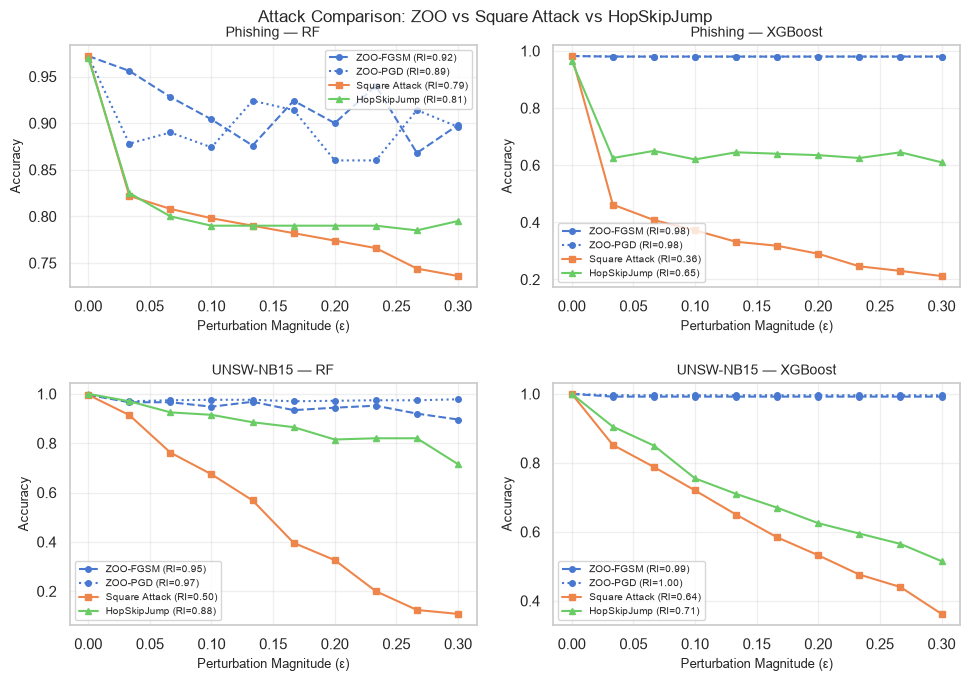

Saved: attack_comparison_curves.png


In [11]:
COLORS = {"zoo_fgsm":"#4878D0","zoo_pgd":"#4878D0",
          "square":"#EE854A","hsj":"#6ACC65"}
STYLES = {"zoo_fgsm":("--","o"),"zoo_pgd":(":","o"),
          "square":("-","s"),  "hsj":("-","^")}
LABELS = {"zoo_fgsm":"ZOO-FGSM","zoo_pgd":"ZOO-PGD",
          "square":"Square Attack","hsj":"HopSkipJump"}

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=False)

for ax, res, title in zip(axes.flat,
        [res_rf_p, res_xgb_p, res_rf_u, res_xgb_u],
        ["Phishing — RF","Phishing — XGBoost",
         "UNSW-NB15 — RF","UNSW-NB15 — XGBoost"]):
    for key in ["zoo_fgsm","zoo_pgd","square","hsj"]:
        ls, mk = STYLES[key]
        ri_val = res["RI"][key]
        ax.plot(EPSILONS, res[key], linestyle=ls, marker=mk,
                color=COLORS[key], label=f"{LABELS[key]} (RI={ri_val:.2f})", markersize=4)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Perturbation Magnitude (ε)", fontsize=9)
    ax.set_ylabel("Accuracy", fontsize=9)
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)

fig.suptitle("Attack Comparison: ZOO vs Square Attack vs HopSkipJump", fontsize=12)
fig.tight_layout(pad=1.5); fig.subplots_adjust(top=0.93)
plt.savefig("attack_comparison_curves.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: attack_comparison_curves.png")


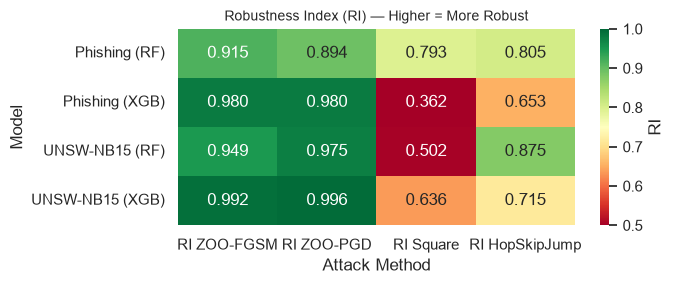

Saved: ri_heatmap_attacks.png


In [12]:
# RI heatmap: models × attacks — easier to read for a paper table
pivot = df_ri.set_index("Model")
fig, ax = plt.subplots(figsize=(7, 3))
sns.heatmap(pivot.astype(float), annot=True, fmt=".3f", cmap="RdYlGn",
            vmin=0.5, vmax=1.0, ax=ax, cbar_kws={"label": "RI"})
ax.set_title("Robustness Index (RI) — Higher = More Robust", fontsize=10)
ax.set_xlabel("Attack Method")
plt.tight_layout()
plt.savefig("ri_heatmap_attacks.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: ri_heatmap_attacks.png")


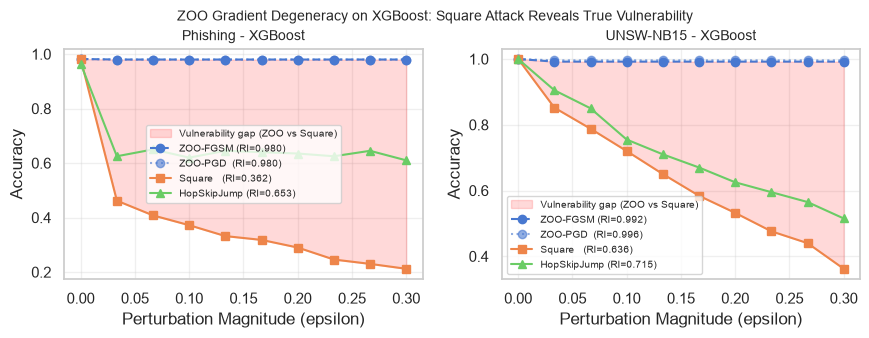

Saved: xgb_attack_degeneracy.png


In [13]:
# Focus plot: XGB ZOO vs Square — the key finding about attack degeneracy
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

for ax, res, title in [(axes[0], res_xgb_p, "Phishing - XGBoost"),
                        (axes[1], res_xgb_u, "UNSW-NB15 - XGBoost")]:
    ri_zf  = res["RI"]["zoo_fgsm"]
    ri_zp  = res["RI"]["zoo_pgd"]
    ri_sq  = res["RI"]["square"]
    ri_hsj = res["RI"]["hsj"]
    ax.fill_between(EPSILONS, res["zoo_fgsm"], res["square"],
                    alpha=0.15, color="red", label="Vulnerability gap (ZOO vs Square)")
    ax.plot(EPSILONS, res["zoo_fgsm"], "o--", color="#4878D0",
            label=f"ZOO-FGSM (RI={ri_zf:.3f})")
    ax.plot(EPSILONS, res["zoo_pgd"],  "o:",  color="#4878D0", alpha=0.6,
            label=f"ZOO-PGD  (RI={ri_zp:.3f})")
    ax.plot(EPSILONS, res["square"],   "s-",  color="#EE854A",
            label=f"Square   (RI={ri_sq:.3f})")
    ax.plot(EPSILONS, res["hsj"],      "^-",  color="#6ACC65",
            label=f"HopSkipJump (RI={ri_hsj:.3f})")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Perturbation Magnitude (epsilon)")
    ax.set_ylabel("Accuracy")
    ax.legend(fontsize=7.5); ax.grid(True, alpha=0.3)

fig.suptitle("ZOO Gradient Degeneracy on XGBoost: Square Attack Reveals True Vulnerability",
             fontsize=10)
fig.tight_layout(pad=1.5); fig.subplots_adjust(top=0.87)
plt.savefig("xgb_attack_degeneracy.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: xgb_attack_degeneracy.png")


In [14]:
# Combined table: prior MLP results + tree results under best attack
MLP = {"Phishing":  {"clean":0.857,"RI_best":0.610},
       "UNSW-NB15": {"clean":0.774,"RI_best":0.692}}

rows_full = []
for dataset, rf_res, xgb_res in [
    ("Phishing",  res_rf_p, res_xgb_p),
    ("UNSW-NB15", res_rf_u, res_xgb_u),
]:
    m = MLP[dataset]
    rf_best  = min(rf_res["RI"].values())
    xgb_best = min(xgb_res["RI"].values())
    rows_full += [
        (dataset, "MLP",     m["clean"],  m["RI_best"],  "FGSM/PGD"),
        (dataset, "RF",      rf_res["RI"]["zoo_fgsm"],
                             rf_best,     "Square/HSJ"),
        (dataset, "XGBoost", xgb_res["RI"]["zoo_fgsm"],
                             xgb_best,    "Square/HSJ"),
    ]

df_full = pd.DataFrame(rows_full,
    columns=["Dataset","Model","RI (ZOO/FGSM)","RI (best attack)","Best attack type"])
print("\n=== Final Robustness Summary — ZOO vs Best Attack ===")
print(df_full.to_string(index=False))
df_full.to_csv("final_robustness_summary.csv", index=False)
print("\nSaved: final_robustness_summary.csv")



=== Final Robustness Summary — ZOO vs Best Attack ===
  Dataset   Model  RI (ZOO/FGSM)  RI (best attack) Best attack type
 Phishing     MLP          0.857             0.610         FGSM/PGD
 Phishing      RF          0.915             0.793       Square/HSJ
 Phishing XGBoost          0.980             0.362       Square/HSJ
UNSW-NB15     MLP          0.774             0.692         FGSM/PGD
UNSW-NB15      RF          0.949             0.502       Square/HSJ
UNSW-NB15 XGBoost          0.992             0.636       Square/HSJ

Saved: final_robustness_summary.csv
